In [1]:
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow and Keras for building CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist

In [3]:
# Loading MNIST dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Checking shape of data
print("Training data shape:", X_train.shape)
print("\n-------------------------------------------------------\n")
print("Testing data shape:", X_test.shape)

Training data shape: (60000, 28, 28)

-------------------------------------------------------

Testing data shape: (10000, 28, 28)


In [4]:
#Data Preprocessing

# Normalizing pixel values (0-255 → 0-1)

X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshaping data to add channel dimension (important for CNN)

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

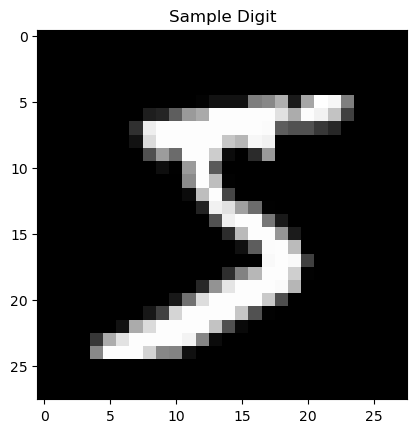

In [5]:
# Displaying some sample images

plt.imshow(X_train[0].reshape(28,28), cmap='gray')
plt.title("Sample Digit")
plt.show()

In [6]:
# Creating CNN model

model = Sequential()

# First convolution layer
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(2,2))

# Second convolution layer
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten layer
model.add(Flatten())

# Dense layer
model.add(Dense(128,activation='relu'))

# Output layer (10 classes → digits 0-9)
model.add(Dense(10,activation='softmax'))

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

C:\Users\Chinmay Pratap Dalvi\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Training model

history = model.fit(X_train, y_train,validation_data=(X_test, y_test),epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 28ms/step - accuracy: 0.9616 - loss: 0.1271 - val_accuracy: 0.9838 - val_loss: 0.0482
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 24ms/step - accuracy: 0.9870 - loss: 0.0420 - val_accuracy: 0.9872 - val_loss: 0.0351
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 31ms/step - accuracy: 0.9913 - loss: 0.0276 - val_accuracy: 0.9908 - val_loss: 0.0299
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9933 - loss: 0.0207 - val_accuracy: 0.9897 - val_loss: 0.0346
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9954 - loss: 0.0147 - val_accuracy: 0.9891 - val_loss: 0.0355


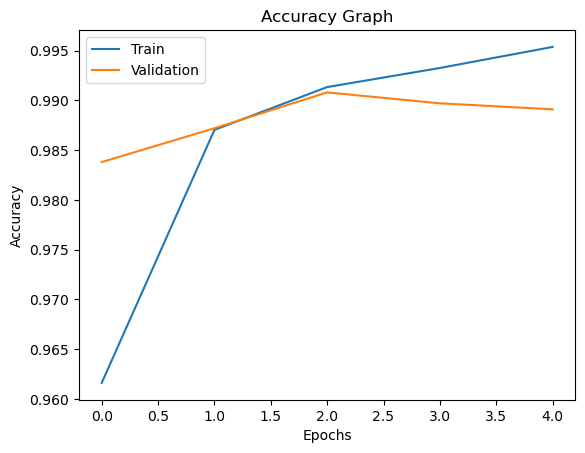

In [8]:
# Plotting accuracy graph

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

In [9]:
# Evaluating model on test data

loss, acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9891 - loss: 0.0355
Test Accuracy: 0.9890999794006348


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Predicted Digit: 7


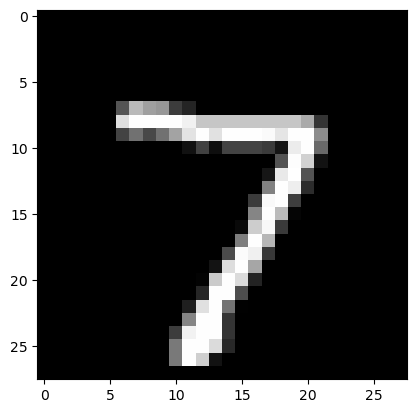

In [10]:
# Predicting a digit

prediction = model.predict(X_test)

# Taking first image
predicted_digit = np.argmax(prediction[0])

print("Predicted Digit:", predicted_digit)

# Show image
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.show()